### There are several ways to establish connection to local postgresql db but we will use pandas and sqlalchemy libraries

### To install it RUN THE NEXT CELL BY CLICKING ON IT AND SHIFT+ENTER or click RUN BUTTON ABOVE

In [1]:
!pip install pandas sqlalchemy


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


### As now we have proper libraries we can import and use them 

### Execute the following cell 

In [2]:
import pandas as pd
from sqlalchemy import create_engine

def connect_to_db(dbname: str, user: str, password: str, host: str = "localhost", port: str = "5432"):
    try:
        conn_str = f"postgresql://{user}:{password}@{host}:{port}/{dbname}"
        engine = create_engine(conn_str)
        print(f"Engine created for database: {dbname}")
        return engine
    except Exception as e:
        print(f"Error creating engine for {dbname}: {e}")
        return None


### in previous cell we creted connect_to_db function which we can reuse to connect to both of our DBs, we just need to provide propper attributers. 

### In the next cell you can find example of establishing connection to SRC DB and reading data from s1.s1_channels into separate pandas dataframe

### Execute the following cell 

In [4]:
src_engine = connect_to_db(
    dbname="dwh_src_hw_db",
    user="postgres",
    password="xh1931"
)

s1_channels_df = pd.read_sql("SELECT * FROM s1.s1_channels", src_engine)
s1_channels_df

Engine created for database: dwh_src_hw_db


,channel_id,channel_name,channel_location
0,1,STORE - 1,621 Hovde Circle
1,2,STORE - 2,9459 Trailsway Terrace
2,3,STORE - 3,23 Transport Street
3,4,STORE - 4,7 Pond Place
4,5,STORE - 5,6799 Armistice Avenue
...,...,...,...
153,154,YAOBAO.COM,Internet
154,155,CATALOG.ONLINER.BY,Internet
155,156,5ELEMENT.BY,Internet
156,157,ALLEGRO.PL,Internet


 ## YOUR TASK IS TO ESTABLISH SEPARATE 

 trg_engine 

 ## and conect to dwh_hw_db in the next cell

In [7]:
trg_engine = connect_to_db(
    dbname="dwh_hw_db",
    user="postgres",
    password="xh1931"
)

lnd_s1_channels_df = pd.read_sql("SELECT * FROM lnd.lnd_s1_channels", trg_engine)
lnd_s1_channels_df

Engine created for database: dwh_hw_db


,channel_id,channel_name,channellocation
0,1,STORE - 1,621 Hovde Circle
1,2,STORE - 2,9459 Trailsway Terrace
2,3,STORE - 3,23 Transport Street
3,4,STORE - 4,7 Pond Place
4,5,STORE - 5,6799 Armistice Avenue
...,...,...,...
151,152,EBAY.COM,N/A - Internet
152,153,ALIEXPRESS.COM,N/A - Internet
153,154,YAOBAO.COM,N/A - Internet
154,155,CATALOG-ONLINER.BY,N/A - Internet


#### AS we have 2 DFs with data from 2 tables we need to compare them. To do so we can create separate DF s1_channels_comparison_df

### Execute the following cell 

In [9]:
s1_channels_comparison_df = s1_channels_df.merge(
    lnd_s1_channels_df,
    on='channel_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True  
)
s1_channels_comparison_df

,channel_id,channel_name_src,channel_location,channel_name_lnd,channellocation,_merge
0,1,STORE - 1,621 Hovde Circle,STORE - 1,621 Hovde Circle,both
1,10,STORE - 10,6840 Pennsylvania Terrace,STORE - 10,6840 Pennsylvania Terrace,both
2,100,STORE - 100,72760 Helena Avenue,STORE - 100,72760 Helena Avenue,both
3,101,STORE - 101,40 Lyons Place,STORE - 101,40 Lyons Place,both
4,102,STORE - 102,04 Ludington Pass,STORE - 102,04 Ludington Pass,both
...,...,...,...,...,...,...
153,95,STORE - 95,6354 Lukken Circle,STORE - 95,6354 Lukken Circle,both
154,96,STORE - 96,1 Lighthouse Bay Way,STORE - 96,1 Lighthouse Bay Way,both
155,97,STORE - 97,03 Moland Parkway,STORE - 97,03 Moland Parkway,both
156,98,STORE - 98,24450 Kim Center,STORE - 98,24450 Kim Center,both


### Since we use indicator=True in the merge, pandas automatically provides the _merge column with values left_only, right_only, or both for the ID values.

### However, we want to make the statuses more meaningful, similar to what we did in SQL and also check for differences in other attributes, not just IDs.
### For this reason, I have prepared a separate function specifically for computing reconciliation_status for the channels table.

### Execute the following cell 

In [16]:
def get_s1_channels_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    mismatches = []
    if row['channel_name_src'] != row['channel_name_lnd']:
        mismatches.append('channel_name')
    if row['channel_location'] != row['channellocation']:
        mismatches.append('channel_location')
    
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    
    return 'Match'

### Since this function expects a single row as input, we can apply it to our s1_channel_comparison_df and create a new column to store the adapted reconciliation statuses.

### Execute the following cell 


In [17]:
s1_channels_comparison_df['reconciliation_status'] = s1_channels_comparison_df.apply(get_s1_channels_reconciliation_status, axis=1)

### And now, let’s keep only the rows with discrepancies (i.e., excluding rows where everything matches).

In [19]:
s1_channels_issues_df = s1_channels_comparison_df[s1_channels_comparison_df['reconciliation_status'] != 'Match']
display(s1_channels_issues_df.head(20))

,channel_id,channel_name_src,channel_location,channel_name_lnd,channellocation,_merge,reconciliation_status
58,151,AMAZON.COM,Internet,AMAZON.COM,N/A - Internet,both,Mismatch in channel_location
59,152,EBAY.COM,Internet,EBAY.COM,N/A - Internet,both,Mismatch in channel_location
60,153,ALIEXPRESS.COM,Internet,ALIEXPRESS.COM,N/A - Internet,both,Mismatch in channel_location
61,154,YAOBAO.COM,Internet,YAOBAO.COM,N/A - Internet,both,Mismatch in channel_location
62,155,CATALOG.ONLINER.BY,Internet,CATALOG-ONLINER.BY,N/A - Internet,both,"Mismatch in channel_name, channel_location"
63,156,5ELEMENT.BY,Internet,5ELEMENT.BY,N/A - Internet,both,Mismatch in channel_location
64,157,ALLEGRO.PL,Internet,NaN,NaN,left_only,Only in source
65,158,AMAZON.COM,Internet,NaN,NaN,left_only,Only in source


# Task: Reconcile all other table pairs from SRC and LND, similar to what we did for the channels table.

## Instructions:

### Tables to compare:

###### s1.s1_products → lnd.lnd_s1_products
###### s1.s1_sales → lnd.lnd_s1_sales
###### s2.s2_channels → lnd.lnd_s2_channels
###### s2.s2_client_sales → lnd.lnd_s2_client_sales
###### s2.s2_clients → lnd.lnd_s2_clients
###### s2.s2_locations → lnd.lnd_s2_locations

## For each table pair:

### 1. Load the SRC and LND tables into pandas DataFrames.
### 2. Perform a full outer merge on the primary key column(s).
### 3. Apply a function like get_reconciliation_status(row) to classify each row into statuses:
###### 'Only in source'
###### 'Only in landing'
###### 'Mismatch in <column_name>'
###### 'Match'

### Keep only rows with issues (statuses != 'Match').

## 4. Create a consolidated result DataFrame with the following columns:

###### table_name	Name of the table being compared
###### key_column	Primary key column used for reconciliation
###### src_id	ID value from source table
###### trg_id	ID value from landing table
###### reconciliation_status	Status of the row (Only in source, Only in landing, etc.)

## 5. Populate the final result DataFrame with all discrepancies from all table comparisons.

### Tips / Methods:

### Use pd.merge(..., how='outer', indicator=True) to combine SRC and LND tables.
### Apply your reconciliation status function row-wise with df.apply(..., axis=1).
### Filter only rows with issues using df[df['reconciliation_status'] != 'Match'].
### Concatenate multiple issues_df DataFrames using pd.concat([...], ignore_index=True) to create the final consolidated DataFrame.

In [20]:
#YOUR CODE HERE AND BELOW
all_reconciliation_issues = []

s1_channels_final = s1_channels_issues_df.copy()
s1_channels_final['table_name'] = 's1_channels'
s1_channels_final['key_column'] = 'channel_id'
s1_channels_final['src_id'] = s1_channels_final['channel_id']
s1_channels_final['trg_id'] = s1_channels_final['channel_id']

all_reconciliation_issues.append(s1_channels_final[['table_name', 'key_column', 'src_id', 'trg_id', 'reconciliation_status']])

In [21]:
def get_reconciliation_results(table_name, src_df, trg_df, key_cols):
    merged = pd.merge(
        src_df, trg_df,
        on=key_cols,
        how='outer',
        suffixes=('_src', '_lnd'),
        indicator=True
    )

    cols_to_check = [c.replace('_src', '') for c in merged.columns if c.endswith('_src') and c.replace('_src', '') not in key_cols]

    def get_status(row):
        if row['_merge'] == 'left_only':
            return 'Only in source'
        if row['_merge'] == 'right_only':
            return 'Only in landing'

        mismatches = []
        for col in cols_to_check:
            lnd_col_name = f"{col}_lnd"
            if lnd_col_name not in row:
                potential_name = col.replace('_', '') + '_lnd'
                lnd_col_name = potential_name if potential_name in row else lnd_col_name

            if str(row[f'{col}_src']) != str(row.get(lnd_col_name, '')):
                mismatches.append(col)

        return f"Mismatch in {', '.join(mismatches)}" if mismatches else 'Match'

    merged['reconciliation_status'] = merged.apply(get_status, axis=1)

    issues = merged[merged['reconciliation_status'] != 'Match'].copy()

    if not issues.empty:
        res_id = issues[key_cols].astype(str).agg('_'.join, axis=1)

        return pd.DataFrame({
            'table_name': table_name,
            'key_column': ', '.join(key_cols),
            'src_id': res_id,
            'trg_id': res_id,
            'reconciliation_status': issues['reconciliation_status']
        })
    return pd.DataFrame()


In [23]:
rc_engine = connect_to_db(dbname="dwh_src_hw_db", user="postgres", password="xh1931")
trg_engine = connect_to_db(dbname="dwh_hw_db", user="postgres", password="xh1931")

tables_to_reconcile = [
    ('s1_products', 's1.s1_products', 'lnd.lnd_s1_products', ['product_id']),
    ('s1_sales', 's1.s1_sales', 'lnd.lnd_s1_sales', ['client_id', 'product_id', 'purchase_date']),
    ('s2_channels', 's2.s2_channels', 'lnd.lnd_s2_channels', ['channel_id']),
    ('s2_client_sales', 's2.s2_client_sales', 'lnd.lnd_s2_client_sales', ['client_id', 'product_id', 'saled_at']),
    ('s2_clients', 's2.s2_clients', 'lnd.lnd_s2_clients', ['client_id']),
    ('s2_locations', 's2.s2_locations', 'lnd.lnd_s2_locations', ['location_id'])
]

for name, src_t, trg_t, keys in tables_to_reconcile:
    df_src = pd.read_sql(f"SELECT * FROM {src_t}", rc_engine)
    df_trg = pd.read_sql(f"SELECT * FROM {trg_t}", trg_engine)

    result_df = get_reconciliation_results(name, df_src, df_trg, keys)

    if not result_df.empty:
        all_reconciliation_issues.append(result_df)

final_consolidated_df = pd.concat(all_reconciliation_issues, ignore_index=True)

display(final_consolidated_df)


Engine created for database: dwh_src_hw_db
Engine created for database: dwh_hw_db


,table_name,key_column,src_id,trg_id,reconciliation_status
0,s1_channels,channel_id,151,151,Mismatch in channel_location
1,s1_channels,channel_id,152,152,Mismatch in channel_location
2,s1_channels,channel_id,153,153,Mismatch in channel_location
3,s1_channels,channel_id,154,154,Mismatch in channel_location
4,s1_channels,channel_id,155,155,"Mismatch in channel_name, channel_location"
...,...,...,...,...,...
208,s2_locations,location_id,19,19,Only in landing
209,s2_locations,location_id,38,38,Only in source
210,s2_locations,location_id,39,39,Only in source
211,s2_locations,location_id,40,40,Only in source


In [24]:
final_consolidated_df.to_csv("reconciliation_results_python.csv", index=False)
print("saved reconciliation_results_python.csv")

saved reconciliation_results_python.csv


## Optional task:

### based on the final result DataFrame build visualizatons 

### Total Anomalies per Table
### Reconciliation Summary by Table
### Reconciliation Status Distribution

## Examples are added

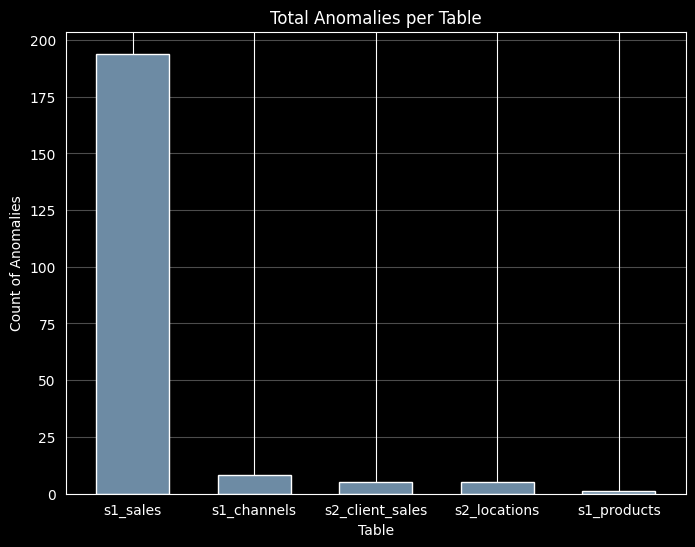

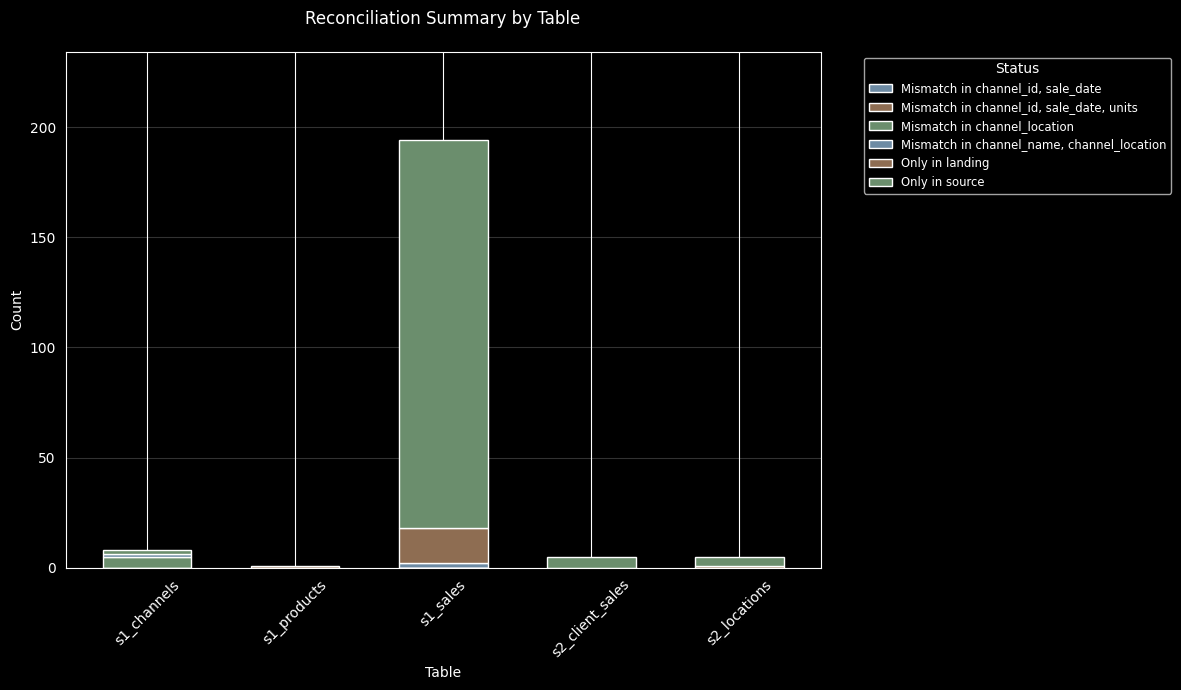

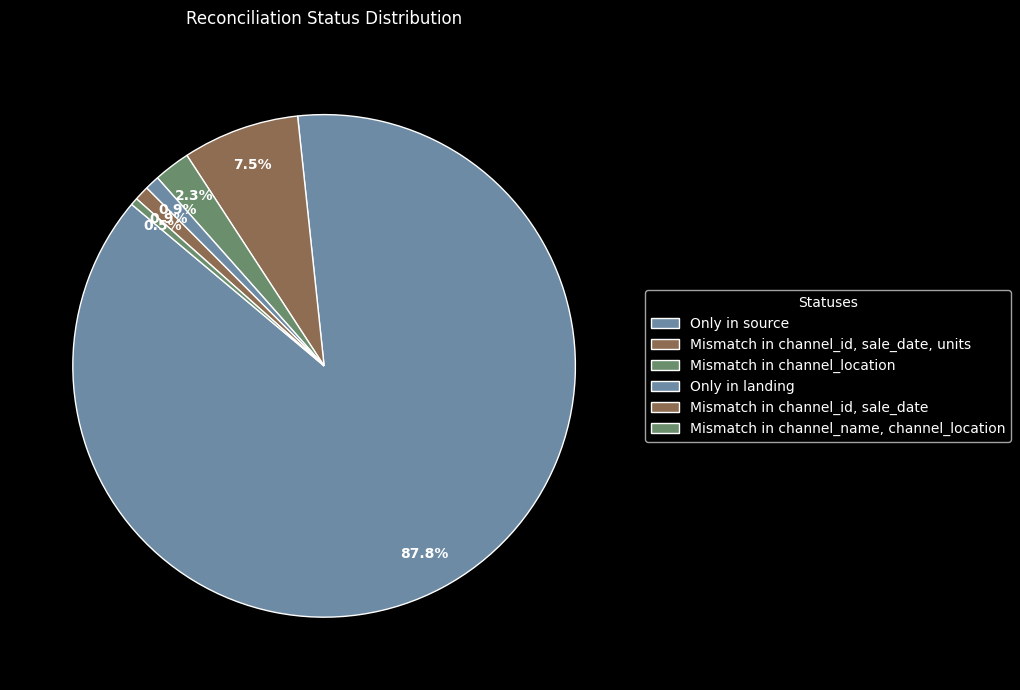

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (8, 6)

custom_colors = ['#6d8ba4', '#8e6d52', '#6b8e6d']

# 1. Total Anomalies per Table
plt.figure()
anomaly_counts = final_consolidated_df['table_name'].value_counts()
anomaly_counts.plot(kind='bar', color='#6d8ba4', width=0.6)
plt.title('Total Anomalies per Table')
plt.xlabel('Table')
plt.ylabel('Count of Anomalies')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

# 2. Reconciliation Summary by Table (Stacked Bar)
plt.figure(figsize=(12, 7))

summary_pivot = final_consolidated_df.groupby(['table_name', 'reconciliation_status']).size().unstack(fill_value=0)

ax = summary_pivot.plot(kind='bar', stacked=True, color=custom_colors, width=0.6, ax=plt.gca())

plt.title('Reconciliation Summary by Table', pad=20)
plt.xlabel('Table')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.2)

plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

current_ylim = plt.ylim()[1]
plt.ylim(0, current_ylim * 1.15)

plt.tight_layout()
plt.show()

# 3. Reconciliation Status Distribution (Pie Chart)
plt.figure(figsize=(10, 7))
status_dist = final_consolidated_df['reconciliation_status'].value_counts()
wedges, texts, autotexts = plt.pie(
    status_dist,
    autopct='%1.1f%%',
    colors=custom_colors,
    startangle=140,
    pctdistance=0.85,
    textprops={'color':"w", 'weight':'bold'}
)
plt.legend(
    wedges,
    status_dist.index,
    title="Statuses",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)
plt.title('Reconciliation Status Distribution', pad=20)
plt.tight_layout()
plt.show()


